# CHEMICAL SIMULATION WITH VQE

This notebook shows how to use VQE in Qiskit Nature to obtain the dissociation profile of a molecule. 

We start by defining the molecule ($H_2$ in this case) and the method we will use to transform the fermionic hamiltonian into a qubit hamiltonian.

In [1]:
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper

driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
    basis="sto3g",
)
problem = driver.run()
mapper = JordanWignerMapper()

Now, we create a VQE instance that will use the UCCSD ansatz to estimate the ground state.

In [2]:
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

initial_state = HartreeFock(
    problem.num_spatial_orbitals, problem.num_particles, mapper
)
ansatz = UCCSD(
    problem.num_spatial_orbitals,
    problem.num_particles,
    mapper,
    initial_state=initial_state,
)

vqe_solver = VQE(StatevectorEstimator(), ansatz, SLSQP())
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

We run it and display the information obtained about the electronic structure.

In [3]:
from qiskit_nature.second_q.algorithms import GroundStateEigensolver

calc = GroundStateEigensolver(mapper, vqe_solver)
res = calc.solve(problem)

print(res)

=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -1.857275030145
  - computed part:      -1.857275030145
~ Nuclear repulsion energy (Hartree): 0.719968994449
> Total ground state energy (Hartree): -1.137306035696
 
=== MEASURED OBSERVABLES ===
 
  0:  # Particles: 2.000 S: 0.000 S^2: 0.000 M: 0.000
 
=== DIPOLE MOMENTS ===
 
~ Nuclear dipole moment (a.u.): [0.0  0.0  1.3889487]
 
  0: 
  * Electronic dipole moment (a.u.): [0.0  0.0  1.388948628839]
    - computed part:      [0.0  0.0  1.388948628839]
  > Dipole moment (a.u.): [0.0  0.0  0.000000071161]  Total: 0.000000071161
                 (debye): [0.0  0.0  0.000000180873]  Total: 0.000000180873
 


/Users/mahdibeigi/Introduction to QC/qiskit_venv/lib/python3.13/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/mahdibeigi/Introduction to QC/qiskit_venv/lib/python3.13/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


For comparison, we can do the same with an exact eigensolver. 

In [4]:
from qiskit_algorithms import NumPyMinimumEigensolver

numpy_solver = NumPyMinimumEigensolver()

calc = GroundStateEigensolver(mapper, numpy_solver)
res = calc.solve(problem)
print(res)

=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -1.857275030202
  - computed part:      -1.857275030202
~ Nuclear repulsion energy (Hartree): 0.719968994449
> Total ground state energy (Hartree): -1.137306035753
 
=== MEASURED OBSERVABLES ===
 
  0:  # Particles: 2.000 S: 0.000 S^2: 0.000 M: 0.000
 
=== DIPOLE MOMENTS ===
 
~ Nuclear dipole moment (a.u.): [0.0  0.0  1.3889487]
 
  0: 
  * Electronic dipole moment (a.u.): [0.0  0.0  1.388948701555]
    - computed part:      [0.0  0.0  1.388948701555]
  > Dipole moment (a.u.): [0.0  0.0  -0.000000001555]  Total: 0.000000001555
                 (debye): [0.0  0.0  -0.000000003953]  Total: 0.000000003953
 


Now we use both the VQE and the exact solver to compute the molecule energy as a function of the distance between the atoms.

In [5]:
import numpy as np

distances = np.linspace(0.25, 3.0, 30)
exact_energies = []
vqe_energies = []
for dist in distances:
    driver = PySCFDriver(
        atom=f"H 0 0 0; H 0 0 {dist}",
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM,
        basis="sto3g",
    )
    problem = driver.run()
    # Exact solver
    calc = GroundStateEigensolver(mapper, numpy_solver)
    res = calc.solve(problem)
    exact_energies.append(res.total_energies[0])
    # VQE
    calc = GroundStateEigensolver(mapper, vqe_solver)
    res = calc.solve(problem)
    vqe_energies.append(res.total_energies[0])

We plot the results

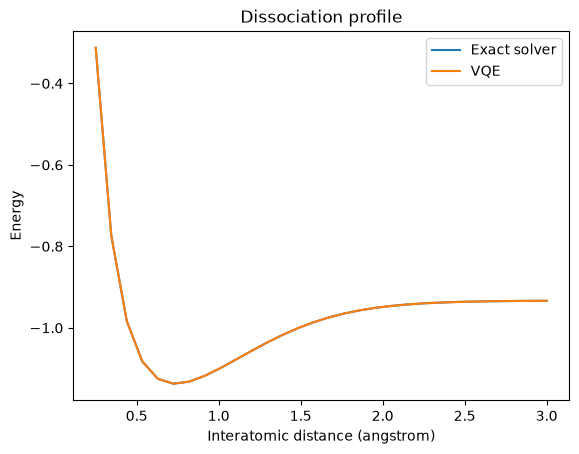

In [6]:
import matplotlib.pyplot as plt

plt.plot(distances, exact_energies, label="Exact solver")
plt.plot(distances, vqe_energies, label="VQE")
plt.title('Dissociation profile')
plt.xlabel('Interatomic distance (angstrom)')
plt.legend()
plt.ylabel('Energy');